# Gaussian Discriminant Analysis (GDA)

## Learning Objectives
- Distinguish **generative** from **discriminative** models: GDA models $p(x \mid y)$ and $p(y)$; logistic regression models $p(y \mid x)$ directly
- Derive the **closed-form MLE** estimates for $\phi$, $\mu_0$, $\mu_1$, $\Sigma$ from the joint log-likelihood
- Show that GDA with shared $\Sigma$ produces a **linear decision boundary** and that the posterior $p(y=1 \mid x)$ is exactly the **logistic sigmoid**
- Understand the **bias-variance trade-off**: GDA is more data-efficient when the Gaussian assumption holds; logistic regression is more robust otherwise
- Implement GDA from scratch using only NumPy with the four closed-form MLE formulas

## Problem Statement

Given a training set $\{(x^{(i)}, y^{(i)})\}_{i=1}^{m}$ with $x^{(i)} \in \mathbb{R}^n$ and $y^{(i)} \in \{0,1\}$, learn a classifier by modelling **how data is generated** rather than the boundary directly.

---

### Generative vs Discriminative

| | Discriminative | Generative |
|---|---|---|
| **Models** | $p(y \mid x)$ directly | $p(x \mid y)$ and $p(y)$ separately |
| **Prediction** | Use $p(y \mid x)$ directly | Bayes' rule: $p(y \mid x) \propto p(x \mid y)\,p(y)$ |
| **Examples** | Logistic regression, SVM | GDA, Naïve Bayes |
| **Assumption** | Fewer | Stronger (distributional form on $x$) |
| **Prefer when** | Non-Gaussian or mixed features | Continuous features, approx Gaussian |

---

### GDA Model Assumptions

GDA assumes:

$\displaystyle y \sim \text{Bernoulli}(\phi)$

$\displaystyle x \mid y=0 \sim \mathcal{N}(\mu_0,\, \Sigma), \qquad x \mid y=1 \sim \mathcal{N}(\mu_1,\, \Sigma)$

**Parameters to learn**: $\theta = (\phi,\, \mu_0,\, \mu_1,\, \Sigma)$ — all from **closed-form MLE**, no iterative optimisation needed.

| Parameter | Shape | Meaning |
|---|---|---|
| $\phi$ | scalar | $P(y=1)$ — class-1 prior |
| $\mu_0$ | $(n,)$ | Mean of class 0 |
| $\mu_1$ | $(n,)$ | Mean of class 1 |
| $\Sigma$ | $(n,n)$ | Shared covariance (LDA assumption) |

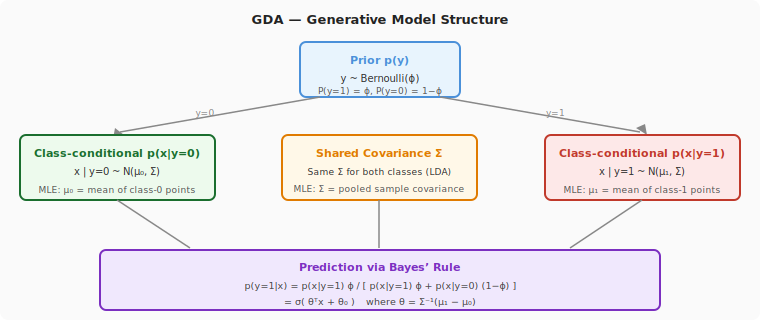

In [7]:
from IPython.display import SVG, display

svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="760" height="320" viewBox="0 0 760 320">
  <rect width="760" height="320" fill="#fafafa" rx="8"/>
  <text x="380" y="24" text-anchor="middle" font-size="13" font-weight="bold" fill="#222">GDA &#x2014; Generative Model Structure</text>

  <!-- Prior box (centered at x=380) -->
  <rect x="300" y="42" width="160" height="55" rx="6" fill="#e8f4fd" stroke="#4a90d9" stroke-width="2"/>
  <text x="380" y="64" text-anchor="middle" font-size="11" font-weight="bold" fill="#4a90d9">Prior p(y)</text>
  <text x="380" y="82" text-anchor="middle" font-size="10" fill="#333">y ~ Bernoulli(&#x3D5;)</text>
  <text x="380" y="94" text-anchor="middle" font-size="9" fill="#555">P(y=1) = &#x3D5;,  P(y=0) = 1&#x2212;&#x3D5;</text>

  <!-- Arrows from Prior to class boxes -->
  <line x1="320" y1="97" x2="120" y2="132" stroke="#888" stroke-width="1.5"/>
  <polygon points="115,128 113,139 124,135" fill="#888"/>
  <text x="205" y="116" text-anchor="middle" font-size="9" fill="#888">y=0</text>

  <line x1="440" y1="97" x2="640" y2="132" stroke="#888" stroke-width="1.5"/>
  <polygon points="636,128 647,135 645,124" fill="#888"/>
  <text x="555" y="116" text-anchor="middle" font-size="9" fill="#888">y=1</text>

  <!-- Class 0 box: x=20 to x=215, center=117.5 -->
  <rect x="20" y="135" width="195" height="65" rx="6" fill="#edfaed" stroke="#1a6e2e" stroke-width="2"/>
  <text x="117" y="157" text-anchor="middle" font-size="11" font-weight="bold" fill="#1a6e2e">Class-conditional p(x|y=0)</text>
  <text x="117" y="175" text-anchor="middle" font-size="10" fill="#333">x | y=0 ~ N(&#x3BC;&#x2080;, &#x3A3;)</text>
  <text x="117" y="193" text-anchor="middle" font-size="9" fill="#555">MLE: &#x3BC;&#x2080; = mean of class-0 points</text>

  <!-- Shared Sigma box: x=282 to x=477, center=379.5 -->
  <rect x="282" y="135" width="195" height="65" rx="6" fill="#fff8e8" stroke="#e07b00" stroke-width="2"/>
  <text x="379" y="157" text-anchor="middle" font-size="11" font-weight="bold" fill="#e07b00">Shared Covariance &#x3A3;</text>
  <text x="379" y="175" text-anchor="middle" font-size="9" fill="#333">Same &#x3A3; for both classes (LDA)</text>
  <text x="379" y="192" text-anchor="middle" font-size="9" fill="#555">MLE: &#x3A3; = pooled sample covariance</text>

  <!-- Class 1 box: x=545 to x=740, center=642.5 -->
  <rect x="545" y="135" width="195" height="65" rx="6" fill="#fde8e8" stroke="#c0392b" stroke-width="2"/>
  <text x="642" y="157" text-anchor="middle" font-size="11" font-weight="bold" fill="#c0392b">Class-conditional p(x|y=1)</text>
  <text x="642" y="175" text-anchor="middle" font-size="10" fill="#333">x | y=1 ~ N(&#x3BC;&#x2081;, &#x3A3;)</text>
  <text x="642" y="193" text-anchor="middle" font-size="9" fill="#555">MLE: &#x3BC;&#x2081; = mean of class-1 points</text>

  <!-- Arrows to Bayes box -->
  <line x1="117" y1="200" x2="190" y2="248" stroke="#888" stroke-width="1.5"/>
  <line x1="379" y1="200" x2="379" y2="248" stroke="#888" stroke-width="1.5"/>
  <line x1="642" y1="200" x2="570" y2="248" stroke="#888" stroke-width="1.5"/>

  <!-- Bayes rule box: x=100, width=560, center=380 -->
  <rect x="100" y="250" width="560" height="60" rx="6" fill="#f0e8fd" stroke="#7b2fc0" stroke-width="2"/>
  <text x="380" y="271" text-anchor="middle" font-size="11" font-weight="bold" fill="#7b2fc0">Prediction via Bayes&#x2019; Rule</text>
  <text x="380" y="289" text-anchor="middle" font-size="9.5" fill="#444">p(y=1|x) = p(x|y=1) &#x3D5; / [ p(x|y=1) &#x3D5; + p(x|y=0) (1&#x2212;&#x3D5;) ]</text>
  <text x="380" y="305" text-anchor="middle" font-size="9.5" fill="#444">= &#x3C3;( &#x3B8;&#x1D40;x + &#x3B8;&#x2080; ) &#x2002; where &#x3B8; = &#x3A3;&#x207B;&#xB9;(&#x3BC;&#x2081; &#x2212; &#x3BC;&#x2080;)</text>
</svg>
"""

display(SVG(svg))

## Model / Hypothesis

GDA defines a **joint model** $p(x, y; \theta) = p(x \mid y; \mu_0, \mu_1, \Sigma) \cdot p(y; \phi)$.

**Class-conditional density** (multivariate Gaussian):

$\displaystyle p(x \mid y=k) = \frac{1}{(2\pi)^{n/2}|\Sigma|^{1/2}} \exp\!\left(-\frac{1}{2}(x-\mu_k)^T \Sigma^{-1}(x-\mu_k)\right)$

**Prediction via Bayes' rule**:

$\displaystyle p(y=1 \mid x) = \frac{p(x \mid y=1)\,\phi}{p(x \mid y=1)\,\phi + p(x \mid y=0)\,(1-\phi)}$

**Key result** — with shared $\Sigma$, the posterior simplifies to:

$\displaystyle p(y=1 \mid x) = \sigma(\theta^T x + \theta_0)$

where $\theta = \Sigma^{-1}(\mu_1 - \mu_0)$ and $\theta_0 = -\frac{1}{2}\mu_1^T\Sigma^{-1}\mu_1 + \frac{1}{2}\mu_0^T\Sigma^{-1}\mu_0 + \log\frac{\phi}{1-\phi}$.

The decision boundary $\{x : \theta^T x + \theta_0 = 0\}$ is a **linear hyperplane** — GDA with shared $\Sigma$ is equivalent to LDA.

## Derivation

**Goal**: maximise the joint log-likelihood $\ell(\phi, \mu_0, \mu_1, \Sigma) = \sum_{i=1}^{m} \log p(x^{(i)}, y^{(i)})$.

Since $\log p(x,y) = \log p(x \mid y) + \log p(y)$, the three parameter groups decouple and can be optimised independently.

---

**Step 1 — MLE for $\phi$** (Bernoulli prior)

$\displaystyle \frac{\partial}{\partial \phi} \sum_i \log p(y^{(i)}) = 0 \quad\Rightarrow\quad \boxed{\hat\phi = \frac{1}{m}\sum_{i=1}^{m} \mathbf{1}\{y^{(i)}=1\}}$

---

**Step 2 — MLE for $\mu_k$** (class means)

The terms in $\ell$ involving $\mu_k$ are $\sum_{i:y^{(i)}=k} -\frac{1}{2}(x^{(i)}-\mu_k)^T\Sigma^{-1}(x^{(i)}-\mu_k)$.  
Setting $\nabla_{\mu_k} = 0$ gives:

$\displaystyle \boxed{\hat\mu_k = \frac{\sum_{i=1}^{m} \mathbf{1}\{y^{(i)}=k\}\, x^{(i)}}{\sum_{i=1}^{m} \mathbf{1}\{y^{(i)}=k\}}} \quad \leftarrow \text{sample mean of class } k$

---

**Step 3 — MLE for $\Sigma$** (pooled covariance)

Maximising over $\Sigma$ using the matrix identity $\nabla_\Sigma \log|\Sigma| = \Sigma^{-T}$ gives:

$\displaystyle \boxed{\hat\Sigma = \frac{1}{m}\sum_{i=1}^{m} (x^{(i)} - \mu_{y^{(i)}})(x^{(i)} - \mu_{y^{(i)}})^T}$

Each residual uses the **class-specific mean** $\mu_{y^{(i)}}$, giving the pooled sample covariance.

---

**Step 4 — Linear boundary (shared $\Sigma$)**

Computing the log-odds $\log[p(y=1\mid x)/p(y=0\mid x)]$ and cancelling the $-\frac{1}{2}\log|\Sigma|$ terms (shared), the quadratic terms $-\frac{1}{2}x^T\Sigma^{-1}x$ also cancel, leaving:

$\displaystyle \log\frac{p(y=1\mid x)}{p(y=0\mid x)} = \underbrace{(\mu_1-\mu_0)^T\Sigma^{-1}}_{\theta^T} x + \theta_0 \quad \leftarrow \text{linear in } x$

## Algorithm: GDA Fit and Predict

All parameters are estimated in **one pass** over the training data — no iterative optimisation.

**Step 1 — Estimate $\hat\phi$**

$\displaystyle \hat\phi = \frac{|\{i : y^{(i)}=1\}|}{m}$

**Step 2 — Estimate $\hat\mu_0$, $\hat\mu_1$**

$\displaystyle \hat\mu_k = \text{mean}(X[y = k]), \quad k \in \{0,1\}$

**Step 3 — Estimate $\hat\Sigma$** (pooled)

$\displaystyle R = X - \hat\mu_{y_i} \quad (\text{subtract each point's class mean}), \qquad \hat\Sigma = \frac{1}{m} R^T R$

**Step 4 — Predict** (for new $x$)

$\quad$ a) Compute $\log p(x \mid y=k) = $ Gaussian log-pdf using $\hat\mu_k$, $\hat\Sigma$

$\quad$ b) Add log-prior: $\log p(x, y=k) = \log p(x \mid y=k) + \log P(y=k)$

$\quad$ c) Posterior via log-sum-exp: $p(y=1 \mid x) = \sigma(\log p(x,y=1) - \log p(x,y=0))$

$\quad$ d) Predict $\hat y = \mathbf{1}[p(y=1 \mid x) \geq 0.5]$

| Quantity | Formula | Shape |
|---|---|---|
| Class prior | $\hat\phi = m_1 / m$ | scalar |
| Class means | $\hat\mu_k = X_k.\text{mean}(0)$ | $(n,)$ each |
| Pooled covariance | $\hat\Sigma = R^T R / m$ | $(n,n)$ |
| Log joint | $\log p(x,y=k)$ | $(m,)$ |
| Posterior | $\sigma(\text{log-odds})$ | $(m,)$ |

## Key Properties

**Closed-form MLE** — unlike logistic regression or neural networks, GDA has no iterative optimisation. All four parameters ($\phi$, $\mu_0$, $\mu_1$, $\Sigma$) have analytical MLE solutions derivable by setting the gradient of the log-likelihood to zero.

**GDA $\Rightarrow$ logistic regression** — if the Gaussian class-conditional assumption holds, the posterior $p(y=1 \mid x) = \sigma(\theta^T x + \theta_0)$ is exactly the logistic sigmoid with $\theta = \Sigma^{-1}(\mu_1 - \mu_0)$. The converse is false: logistic regression makes no assumption on $p(x \mid y)$.

**Data efficiency trade-off** — if the Gaussian assumption holds, GDA needs fewer examples to reach the same accuracy as logistic regression (lower variance from the structural prior). If the assumption fails, GDA is biased and logistic regression wins.

**LDA vs QDA** — sharing $\Sigma$ across classes (LDA) produces a linear boundary and pools covariance estimates for lower variance. Using separate $\Sigma_0$, $\Sigma_1$ (QDA) allows a quadratic boundary at the cost of $O(n^2)$ extra parameters per class.

**Singularity risk** — $\hat\Sigma$ is singular when $n > m$ (more features than samples). Fix with regularisation: $\hat\Sigma \leftarrow \hat\Sigma + \lambda I$ (ridge) or use dimensionality reduction first.

**Multiclass extension** — GDA generalises naturally to $K > 2$ classes: fit one Gaussian $\mathcal{N}(\mu_k, \Sigma)$ per class, then classify by $\hat y = \arg\max_k [\log p(x \mid y=k) + \log P(y=k)]$.

In [6]:
import numpy as np
from scipy.stats import multivariate_normal


def fit(X, y):
    """
    Fit binary GDA (LDA) via closed-form MLE.

    Inputs
    ------
    X : np.ndarray, shape (m, n)  — feature matrix (no bias column needed)
    y : np.ndarray, shape (m,)    — binary labels in {0, 1}

    Outputs
    -------
    phi   : float                 — MLE prior P(y=1)
    mu    : dict {0: (n,), 1: (n,)} — MLE class means
    Sigma : np.ndarray, shape (n, n) — MLE pooled covariance
    """
    m = len(y)

    # Step 1: phi — fraction of class-1 examples
    phi = float(np.mean(y == 1))

    # Step 2: class means
    mu = {k: X[y == k].mean(axis=0) for k in (0, 1)}

    # Step 3: pooled covariance — subtract each point's class mean
    mu_yi = np.where(y[:, None] == 1, mu[1], mu[0])   # (m, n) class means per sample
    R     = X - mu_yi                                   # (m, n) residuals
    Sigma = (R.T @ R) / m                               # (n, n) pooled MLE covariance

    return phi, mu, Sigma


def predict_proba(X, phi, mu, Sigma):
    """
    Compute posterior P(y=1 | x) via Bayes' rule and log-sum-exp.

    Inputs
    ------
    X     : np.ndarray, shape (m, n)    — feature matrix
    phi   : float                       — prior P(y=1)
    mu    : dict {0: (n,), 1: (n,)}     — class means
    Sigma : np.ndarray, shape (n, n)    — shared covariance

    Output
    ------
    proba : np.ndarray, shape (m,)  — P(y=1 | x) for each sample
    """
    log_joint_0 = multivariate_normal.logpdf(X, mu[0], Sigma) + np.log(1.0 - phi)
    log_joint_1 = multivariate_normal.logpdf(X, mu[1], Sigma) + np.log(phi)
    # p(y=1|x) = exp(lp1) / [exp(lp0) + exp(lp1)]  = sigmoid(lp1 - lp0)
    log_odds = log_joint_1 - log_joint_0
    return 1.0 / (1.0 + np.exp(-log_odds))             # sigmoid(log-odds)


def predict(X, phi, mu, Sigma, threshold=0.5):
    """
    Predict binary class labels.

    Inputs
    ------
    X         : np.ndarray, shape (m, n)  — feature matrix
    phi       : float                     — prior P(y=1)
    mu        : dict {0: (n,), 1: (n,)}   — class means
    Sigma     : np.ndarray, shape (n, n)  — shared covariance
    threshold : float                     — decision threshold (default 0.5)

    Output
    ------
    y_hat : np.ndarray, shape (m,)  — predicted labels in {0, 1}
    """
    return (predict_proba(X, phi, mu, Sigma) >= threshold).astype(int)